In [ ]:
# Ejecuta esta celda para instalar todas las librerías necesarias
!pip install tensorflow pillow matplotlib scipy scikit-learn

In [11]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
# === Parameters ===
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
BASE_DIR = Path.cwd()
TEST_DATA_DIR = BASE_DIR / "Fish_Dataset_Splitted" / "test"

# === Data Generators ===
# Custom model has Rescaling(1./255) built-in, so no preprocessing function needed
test_datagen_custom = ImageDataGenerator()
test_generator_custom = test_datagen_custom.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# VGG16 preprocessing
test_datagen_vgg16 = ImageDataGenerator(preprocessing_function=preprocess_vgg16)
test_generator_vgg16 = test_datagen_vgg16.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

# MobileNetV2 preprocessing
test_datagen_mobilenet = ImageDataGenerator(preprocessing_function=preprocess_mobilenetv2)
test_generator_mobilenet = test_datagen_mobilenet.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

class_names = list(test_generator_custom.class_indices.keys())


Found 500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


In [3]:
# === Load Models ===
print("Cargando modelo Custom...")
model_custom = load_model("modelo_peces_Custom.keras")

print("Cargando modelo VGG16...")
model_vgg16 = load_model("modelo_peces_vgg16.keras")

print("Cargando modelo MobileNetV2...")
model_mobilenet = load_model("modelo_peces_MobileNetV2.keras")



Cargando modelo Custom...
Cargando modelo VGG16...
Cargando modelo MobileNetV2...


In [5]:
# === Evaluate Models ===
print("\nEvaluando modelo Custom...")
loss_custom, acc_custom = model_custom.evaluate(test_generator_custom, verbose=1)

print("\nEvaluando modelo VGG16...")
loss_vgg16, acc_vgg16 = model_vgg16.evaluate(test_generator_vgg16, verbose=1)

print("\nEvaluando modelo MobileNetV2...")
loss_mobilenet, acc_mobilenet = model_mobilenet.evaluate(test_generator_mobilenet, verbose=1)

print("\n=== Resultados de Evaluación en Test ===")
print(f"Custom      - Accuracy: {acc_custom:.4f}, Loss: {loss_custom:.4f}")
print(f"VGG16       - Accuracy: {acc_vgg16:.4f}, Loss: {loss_vgg16:.4f}")
print(f"MobileNetV2       - Accuracy: {acc_mobilenet:.4f}, Loss: {loss_mobilenet:.4f}")


Evaluando modelo Custom...
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 300ms/step - accuracy: 0.9980 - loss: 0.0159

Evaluando modelo VGG16...
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9940 - loss: 0.0125

Evaluando modelo MobileNetV2...
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 549ms/step - accuracy: 1.0000 - loss: 0.0213

=== Resultados de Evaluación en Test ===
Custom      - Accuracy: 0.9980, Loss: 0.0159
VGG16       - Accuracy: 0.9940, Loss: 0.0125
MobileNetV2       - Accuracy: 1.0000, Loss: 0.0213


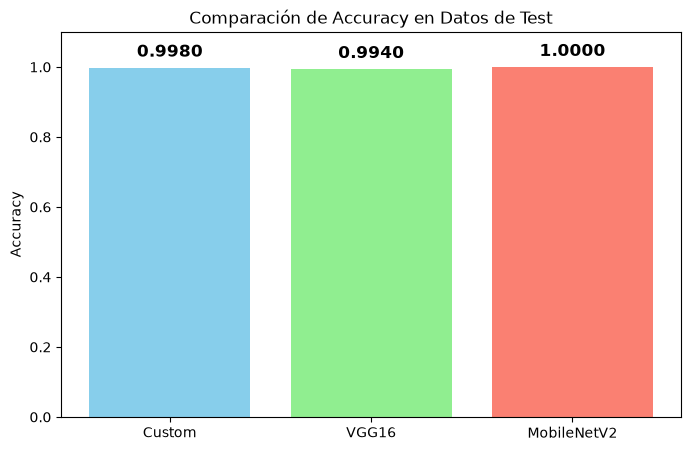

In [6]:
# === Graph Accuracy Comparison ===
models = ['Custom', 'VGG16', 'MobileNetV2']
accuracies = [acc_custom, acc_vgg16, acc_mobilenet]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1.1)
plt.title('Comparación de Accuracy en Datos de Test')
plt.ylabel('Accuracy')

# Añadir etiquetas de datos
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')




Generando predicciones para Custom Model...
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 323ms/step


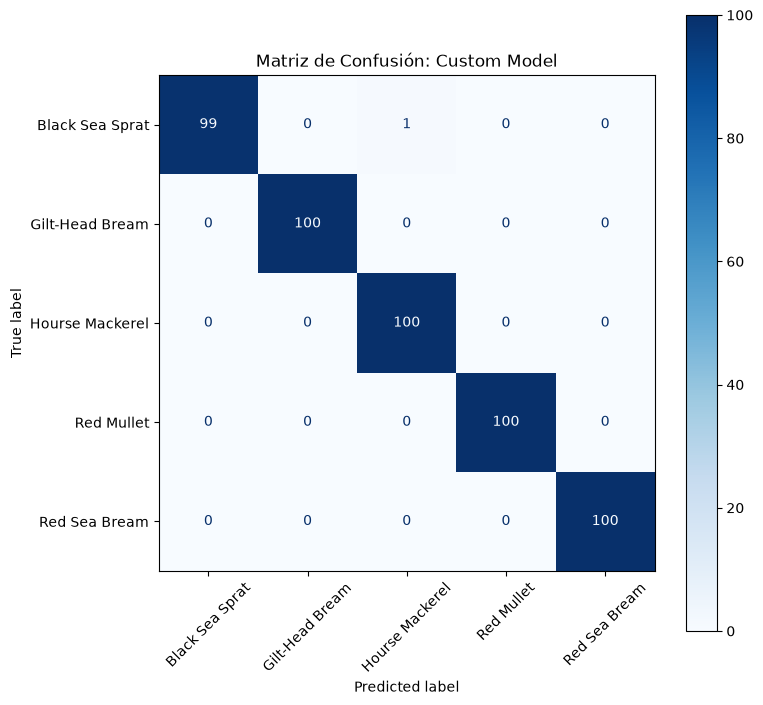


Generando predicciones para VGG16...
16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step


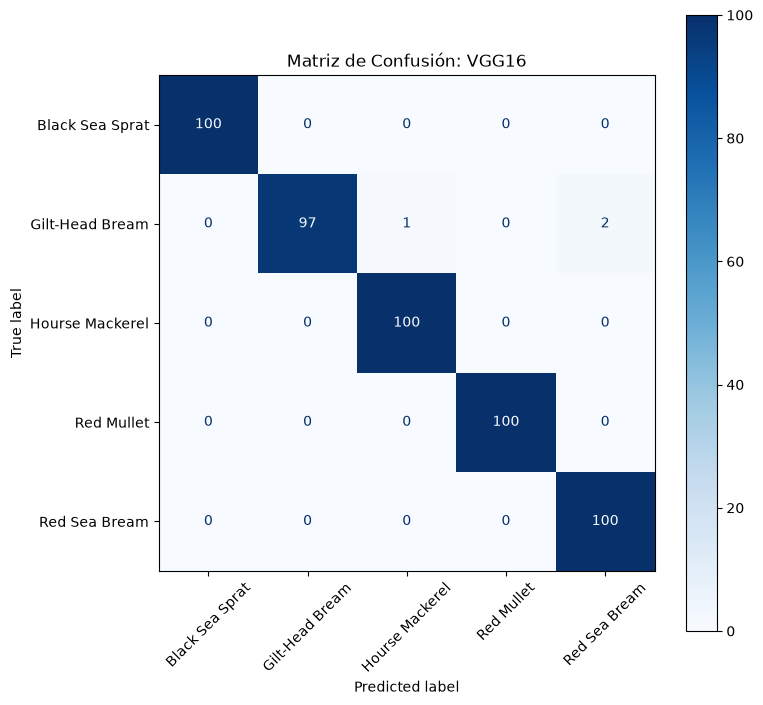


Generando predicciones para MobileNet2...
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 520ms/step


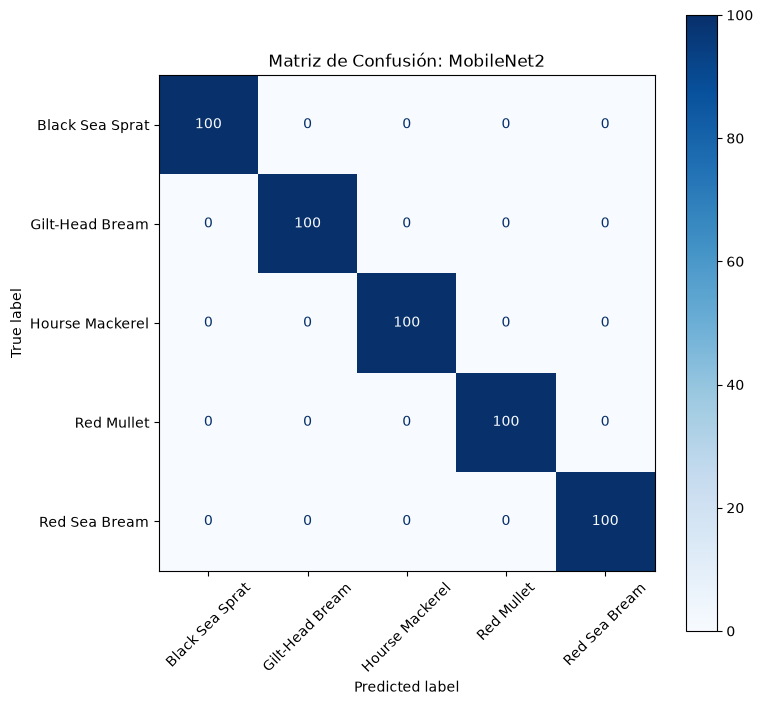

In [13]:
# === Confusion Matrices ===
def plot_cm(model, generator, title):
    print(f"\nGenerando predicciones para {title}...")
    generator.reset()
    preds = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title(f'Matriz de Confusión: {title}')
    plt.show()

plot_cm(model_custom, test_generator_custom, "Custom Model")
plot_cm(model_vgg16, test_generator_vgg16, "VGG16")
plot_cm(model_mobilenet, test_generator_mobilenet, "MobileNet2")
